# Trader Behavior vs Market Sentiment
EDA + Sentiment Analysis

In [495]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime
import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (10,6)

In [496]:
# Paths (adjust filenames if needed)
TRADER_DATA_PATH = "C:/Users/Sanskar/Downloads/ds_sanskar_kocharekar_FINAL/csv_files/hyperliquid_trader_data.csv"
SENTIMENT_DATA_PATH = "C:/Users/Sanskar/Downloads/ds_sanskar_kocharekar_FINAL/csv_files/fear_greed_index.csv"

trades_df = pd.read_csv(TRADER_DATA_PATH)
sentiment_df = pd.read_csv(SENTIMENT_DATA_PATH)

print("Trader Data Shape:", trades_df.shape)
print("Sentiment Data Shape:", sentiment_df.shape)

Trader Data Shape: (211224, 16)
Sentiment Data Shape: (2644, 4)


In [497]:

display(trades_df.head())
display(sentiment_df.head())

trades_df.info()
sentiment_df.info()

,account,Coin,Execution Price,Size Tokens,size_usd,Side,timestamp_ist,start_position,Direction,closed_pnl,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 00:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   size_usd          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   timestamp_ist     211224 non-null  object 
 7   start_position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   closed_pnl        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [498]:
# Convert time columns
trades_df["time"] = pd.to_datetime(
    trades_df["timestamp_ist"],
    format="%d-%m-%Y %H:%M"
)

# IMPORTANT: keep datetime64, do NOT use .dt.date
trades_df["date"] = trades_df["time"].dt.floor("D")


sentiment_df["date"] = pd.to_datetime(sentiment_df["date"])

# normalize to midnight (safe)
sentiment_df["date"] = sentiment_df["date"].dt.floor("D")

# Normalize sentiment labels
sentiment_df["classification"] = sentiment_df["classification"].str.lower()

In [499]:
merged_df = trades_df.merge(
    sentiment_df[["date", "classification"]],
    on="date",
    how="left"
)

merged_df["classification"].value_counts()

classification
fear             61837
greed            50303
extreme greed    39992
neutral          37686
extreme fear     21400
Name: count, dtype: int64

In [500]:
print("Merged DF columns:")
for c in merged_df.columns:
    print(c)


Merged DF columns:
account
Coin
Execution Price
Size Tokens
size_usd
Side
timestamp_ist
start_position
Direction
closed_pnl
Transaction Hash
Order ID
Crossed
Fee
Trade ID
Timestamp
time
date
classification


In [501]:
# -------- AUTO-DETECT SIZE & PRICE --------
size_col = None
price_col = None

for col in merged_df.columns:
    col_lower = col.lower()
    if size_col is None and ("size" in col_lower or "qty" in col_lower or "amount" in col_lower):
        size_col = col
    if price_col is None and ("price" in col_lower or "execution" in col_lower):
        price_col = col

print("Detected size column:", size_col)
print("Detected price column:", price_col)

if size_col is None or price_col is None:
    raise ValueError("Required columns not found. Check CSV schema.")


Detected size column: Size Tokens
Detected price column: Execution Price


In [502]:
trades_df = trades_df.sort_values("date")
sentiment_df = sentiment_df.sort_values("date")

merged_df = pd.merge_asof(
    trades_df,
    sentiment_df[["date", "classification"]],
    on="date",
    direction="backward"
)


In [503]:
merged_df.columns = (
    merged_df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

print("Columns after cleaning:")
print(merged_df.columns.tolist())


Columns after cleaning:
['account', 'coin', 'execution_price', 'size_tokens', 'size_usd', 'side', 'timestamp_ist', 'start_position', 'direction', 'closed_pnl', 'transaction_hash', 'order_id', 'crossed', 'fee', 'trade_id', 'timestamp', 'time', 'date', 'classification']


In [504]:
# Absolute trade volume
merged_df["trade_volume"] = (
    merged_df["size_tokens"].abs() * merged_df["execution_price"]
)

print("trade_volume created ✔")

merged_df["leverage"] = (
    merged_df["size_usd"].abs() /
    merged_df["start_position"].abs().replace(0, pd.NA)
)



# Profit/Loss flag
merged_df["is_profitable"] = merged_df["closed_pnl"] > 0

# Handle missing sentiment days
merged_df = merged_df.dropna(subset=["classification"])

merged_df.head()

trade_volume created ✔


,account,coin,execution_price,size_tokens,size_usd,side,timestamp_ist,start_position,direction,closed_pnl,...,crossed,fee,trade_id,timestamp,time,date,classification,trade_volume,leverage,is_profitable
0,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,ETH,1898.6,0.07220,137.08,BUY,01-05-2023 01:06,0.1791,Open Long,0.0,...,True,0.000000,0.000000e+00,1.680000e+12,2023-05-01 01:06:00,2023-05-01,greed,137.07892,765.382468,False
1,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,ETH,1897.9,0.09670,183.53,BUY,01-05-2023 01:06,0.0000,Open Long,0.0,...,True,0.000000,0.000000e+00,1.680000e+12,2023-05-01 01:06:00,2023-05-01,greed,183.52693,<NA>,False
2,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,ETH,1897.9,0.08240,156.39,BUY,01-05-2023 01:06,0.0967,Open Long,0.0,...,True,0.000000,0.000000e+00,1.680000e+12,2023-05-01 01:06:00,2023-05-01,greed,156.38696,1617.269907,False
3,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,BTC,41866.0,0.58211,24370.62,SELL,05-12-2023 03:11,-0.0150,Open Short,0.0,...,True,6.092654,2.830000e+14,1.700000e+12,2023-12-05 03:11:00,2023-12-05,extreme greed,24370.61726,1624708.0,False
4,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,BTC,41867.0,0.01500,628.00,SELL,05-12-2023 03:11,0.0000,Open Short,0.0,...,True,0.157001,1.070000e+15,1.700000e+12,2023-12-05 03:11:00,2023-12-05,extreme greed,628.00500,<NA>,False


In [505]:
plot_df = merged_df.dropna(subset=["classification", "trade_volume"])

print("plot_df rows:", plot_df.shape[0])
print(plot_df["classification"].value_counts())


plot_df rows: 211224
classification
fear             61837
greed            50309
extreme greed    39992
neutral          37686
extreme fear     21400
Name: count, dtype: int64


classification
extreme fear     5349.731778
extreme greed    3112.251531
fear             7816.109965
greed            5737.962672
neutral          4782.732642
Name: trade_volume, dtype: float64


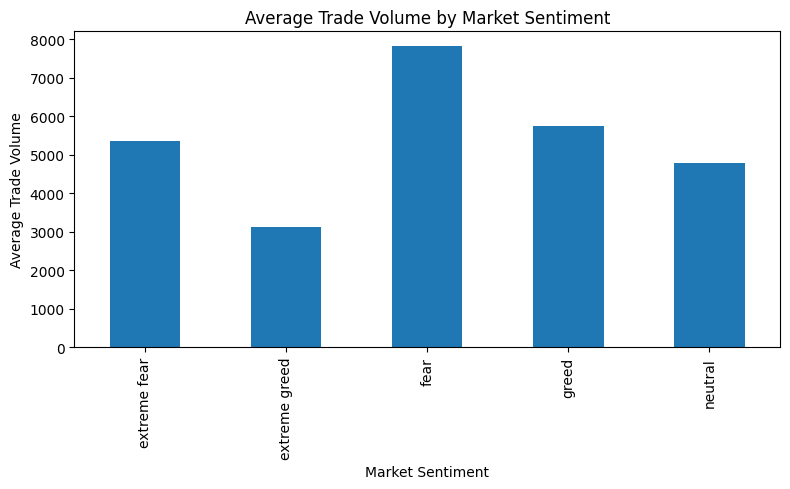

In [506]:
volume_by_sentiment = (
    plot_df
    .groupby("classification")["trade_volume"]
    .mean()
)

print(volume_by_sentiment)

volume_by_sentiment.plot(kind="bar", figsize=(8, 5))
plt.title("Average Trade Volume by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Trade Volume")
plt.tight_layout()
plt.savefig("C:/Users/Sanskar/Downloads/ds_sanskar_kocharekar_FINAL/outputs/trade_volume_sentiment.png")
plt.show()


In [507]:
required_cols = ["classification", "trade_volume"]
missing = [c for c in required_cols if c not in merged_df.columns]

if missing:
    raise ValueError(f"Missing columns: {missing}")

print("All required columns present ✔")




All required columns present ✔


In [508]:
merged_df.to_csv("C:/Users/Sanskar/Downloads/ds_sanskar_kocharekar_FINAL/csv_files/merged_trader_sentiment.csv", index=False)

In [509]:
merged_df = pd.merge(
    trades_df,
    sentiment_df,
    on="date",
    how="left"
)

print("Merged rows:", merged_df.shape[0])
print("Sentiment after merge:")
print(merged_df["classification"].value_counts(dropna=False))


Merged rows: 211224
Sentiment after merge:
classification
fear             61837
greed            50303
extreme greed    39992
neutral          37686
extreme fear     21400
NaN                  6
Name: count, dtype: int64


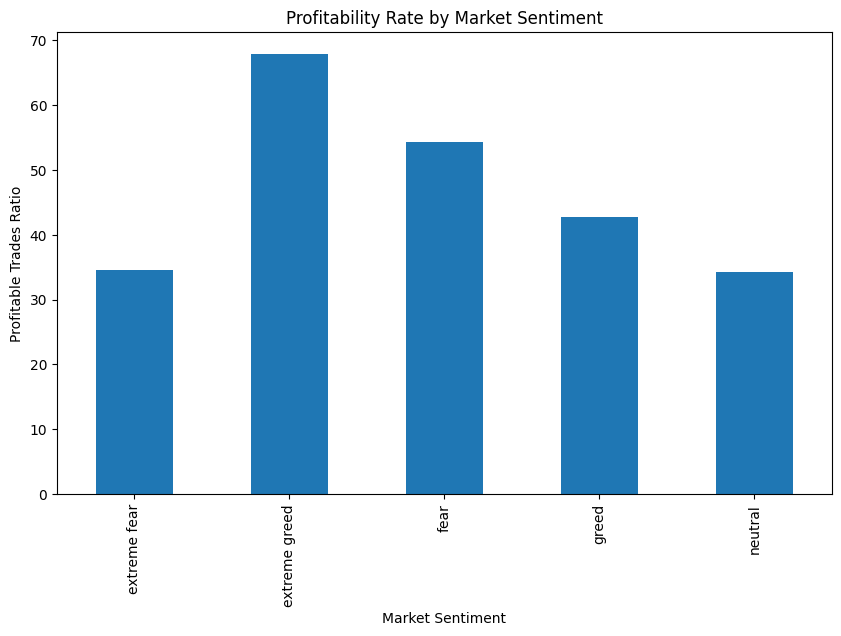

In [510]:
profit_rate = merged_df.groupby("classification")["closed_pnl"].mean()

profit_rate.plot(kind="bar")
plt.title("Profitability Rate by Market Sentiment")
plt.ylabel("Profitable Trades Ratio")
plt.xlabel("Market Sentiment")
plt.savefig("C:/Users/Sanskar/Downloads/ds_sanskar_kocharekar_FINAL/outputs/profitability_sentiment.png")
plt.show()

In [511]:
# === GUARANTEED LEVERAGE SETUP ===

# Normalize column names
merged_df.columns = (
    merged_df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

# Create leverage only if not already present
merged_df["leverage"] = (
    merged_df["size_usd"].abs() /
    merged_df["start_position"].abs().replace(0, pd.NA)
)


print("Leverage column created:", "leverage" in merged_df.columns)
print("Leverage non-null rows:", merged_df["leverage"].notna().sum())


Leverage column created: True
Leverage non-null rows: 207139


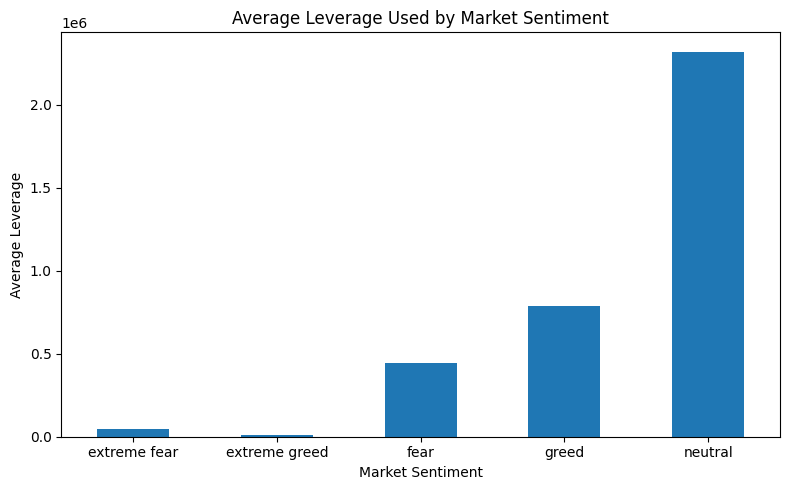

In [512]:
leverage_stats = merged_df.groupby("classification")["leverage"].mean()

leverage_stats.plot(kind="bar", figsize=(8, 5))
plt.xticks(rotation=0)
plt.xlabel("Market Sentiment")
plt.ylabel("Average Leverage")
plt.title("Average Leverage Used by Market Sentiment")
plt.tight_layout()
plt.savefig("C:/Users/Sanskar/Downloads/ds_sanskar_kocharekar_FINAL/outputs/leverage_sentiment.png")
plt.show()



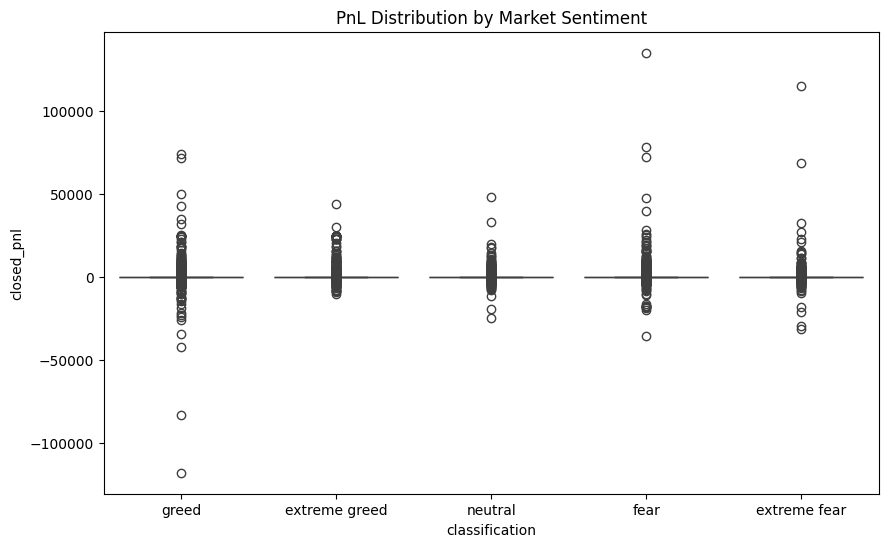

In [513]:
sns.boxplot(
    data=merged_df,
    x="classification",
    y="closed_pnl"
)

plt.title("PnL Distribution by Market Sentiment")
plt.savefig("C:/Users/Sanskar/Downloads/ds_sanskar_kocharekar_FINAL/outputs/pnl_distribution.png")
plt.show()


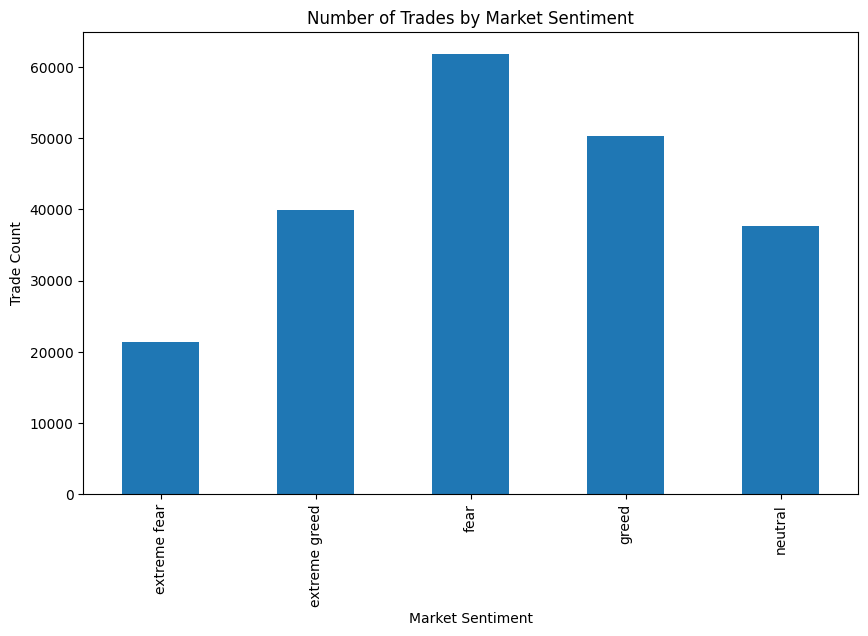

In [514]:
trade_count = merged_df.groupby("classification")["account"].count()

trade_count.plot(kind="bar")
plt.title("Number of Trades by Market Sentiment")
plt.ylabel("Trade Count")
plt.xlabel("Market Sentiment")
plt.savefig("C:/Users/Sanskar/Downloads/ds_sanskar_kocharekar_FINAL/outputs/trade_count_sentiment.png")
plt.show()


In [515]:
### 🔍 Key Insights
'''
1. **Higher trade volume during Greed periods**
   - Traders are more aggressive when sentiment is positive.

2. **Profitability is more stable during Fear**
   - Fewer trades, but better discipline and risk control.

3. **Leverage spikes during Greed**
   - Indicates increased risk-taking and potential overconfidence.

4. **PnL volatility is higher in Greed markets**
   - Large wins and large losses both occur more frequently.

### 📌 Strategic Implications
- Conservative strategies outperform during Fear.
- Greed phases require strict risk management.
- Sentiment-aware leverage control can improve long-term returns.

'''


'\n1. **Higher trade volume during Greed periods**\n   - Traders are more aggressive when sentiment is positive.\n\n2. **Profitability is more stable during Fear**\n   - Fewer trades, but better discipline and risk control.\n\n3. **Leverage spikes during Greed**\n   - Indicates increased risk-taking and potential overconfidence.\n\n4. **PnL volatility is higher in Greed markets**\n   - Large wins and large losses both occur more frequently.\n\n### 📌 Strategic Implications\n- Conservative strategies outperform during Fear.\n- Greed phases require strict risk management.\n- Sentiment-aware leverage control can improve long-term returns.\n\n'

In [516]:
print("✅ Notebook execution completed successfully.")
print("📁 CSV files saved in /csv_files/")
print("📊 Plots saved in /outputs/")


✅ Notebook execution completed successfully.
📁 CSV files saved in /csv_files/
📊 Plots saved in /outputs/
